In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2285s 13us/step


In [ ]:
print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [ ]:
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [ ]:
plt.rcParams['font.family'] = 'Serif'
plt.rcParams['font.size'] = 12

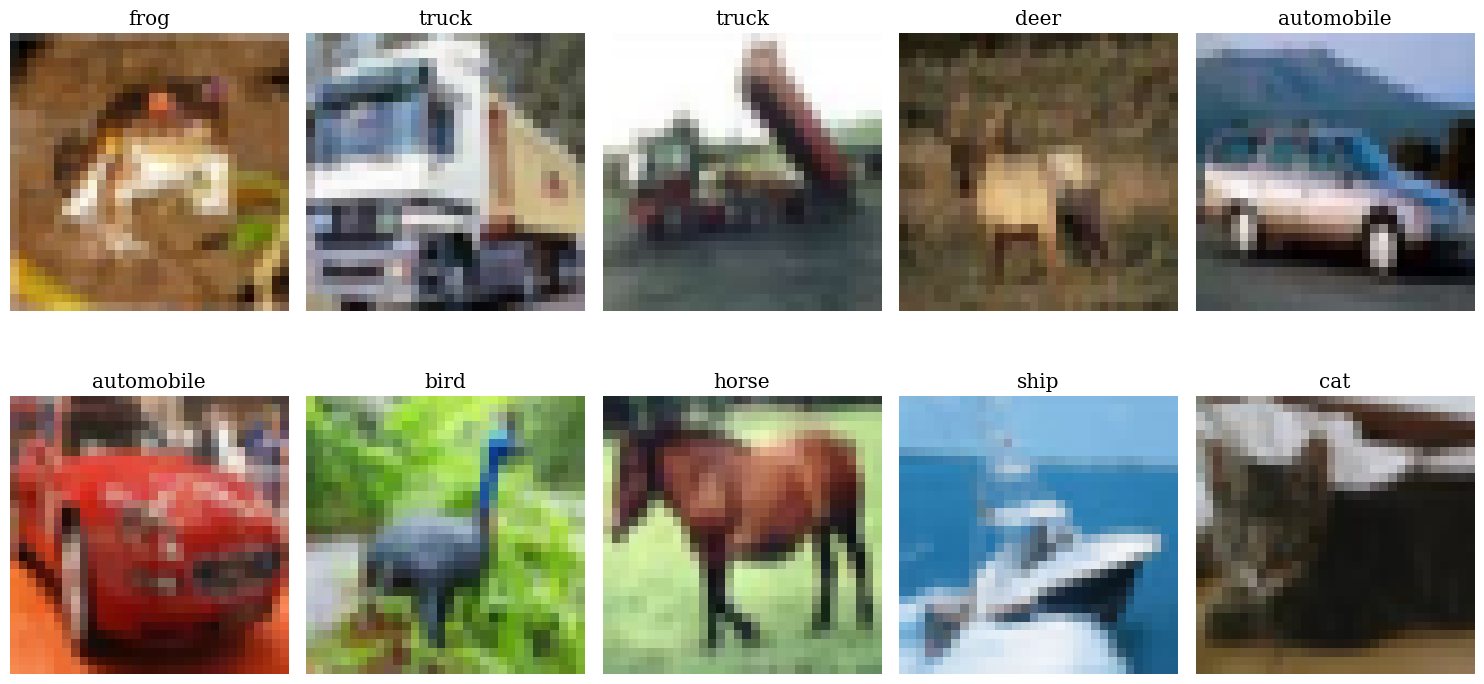

In [ ]:
plt.figure(figsize=(15,8))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(X_train[i])
  plt.title(class_names[y_train[i][0]],fontname='Serif')
  plt.axis('off')
plt.savefig("training_samples.eps",format="eps",dpi=600,bbox_inches="tight")
plt.tight_layout()
plt.show()

In [ ]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [ ]:
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


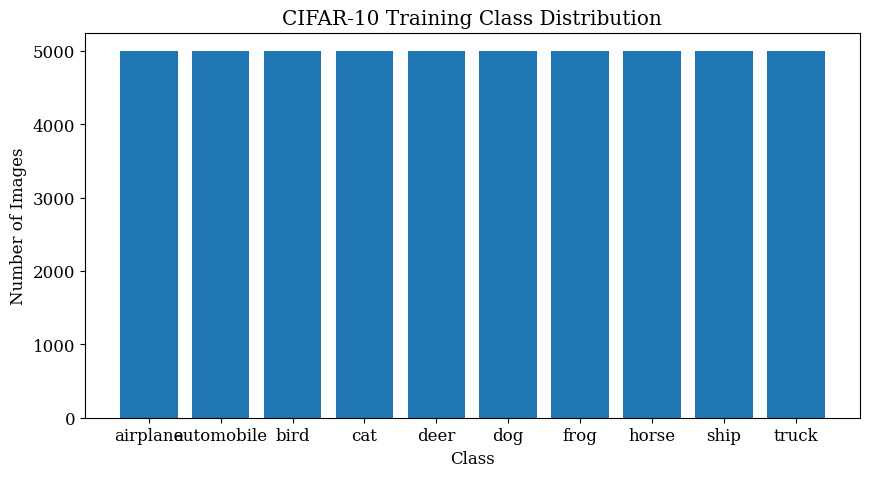

In [ ]:
#Class Distribution
class_counts = np.bincount(y_train.flatten())
plt.figure(figsize=(10, 5))
plt.bar(class_names, class_counts)
plt.xlabel("Class",fontname='Serif')
plt.ylabel("Number of Images",fontname='Serif')
plt.title("CIFAR-10 Training Class Distribution",fontname='Serif')
plt.savefig("class_distribution.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [ ]:
sample_img = X_train[0:1]

kernel_sizes = [3, 5, 7]
print(f"{'Kernel':<10}{'Output Shape':<20}{'Formula Check (valid, stride=1)'}")
for k in kernel_sizes:
    conv = layers.Conv2D(filters=8, kernel_size=(k, k), strides=1, padding='valid')
    out = conv(sample_img)
    N, F, P, S = 32, k, 0, 1
    formula_size = (N - F + 2 * P) // S + 1
    print(f"{k}x{k:<7}{str(out.shape):<20}expected {formula_size}x{formula_size}")


Kernel    Output Shape        Formula Check (valid, stride=1)
3x3      (1, 30, 30, 8)      expected 30x30
5x5      (1, 28, 28, 8)      expected 28x28
7x7      (1, 26, 26, 8)      expected 26x26


In [ ]:
configs = [
    {"stride": 1, "padding": "valid"},
    {"stride": 2, "padding": "valid"},
    {"stride": 1, "padding": "same"},
    {"stride": 2, "padding": "same"},
]

print(f"{'Stride':<8}{'Padding':<10}{'Output Shape'}")
for cfg in configs:
    conv = layers.Conv2D(filters=8, kernel_size=(3, 3),
                          strides=cfg["stride"], padding=cfg["padding"])
    out = conv(sample_img)
    print(f"{cfg['stride']:<8}{cfg['padding']:<10}{out.shape}")


Stride  Padding   Output Shape
1       valid     (1, 30, 30, 8)
2       valid     (1, 15, 15, 8)
1       same      (1, 32, 32, 8)
2       same      (1, 16, 16, 8)


In [ ]:
# Build CNN Model
model = models.Sequential([
    layers.Conv2D(filters=32,kernel_size=(3, 3),padding='same',activation='relu',input_shape=(32, 32, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=64,kernel_size=(3, 3),padding='same',activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32,validation_split=0.2, verbose=1)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4918 - loss: 1.4150 - val_accuracy: 0.5992 - val_loss: 1.1524
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6326 - loss: 1.0460 - val_accuracy: 0.6477 - val_loss: 1.0331
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6832 - loss: 0.9061 - val_accuracy: 0.6768 - val_loss: 0.9434
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7160 - loss: 0.8089 - val_accuracy: 0.6625 - val_loss: 0.9704
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7480 - loss: 0.7252 - val_accuracy: 0.6905 - val_loss: 0.9279
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7714 - loss: 0.6478 - val_accuracy: 0.6885 - val_loss: 0.9748
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7998 - loss: 0.5716 - val_accuracy: 0.6912 - val_loss: 0.9404
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8239 - loss: 0.4994 -

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
Feature map shape: (1, 32, 32, 32)


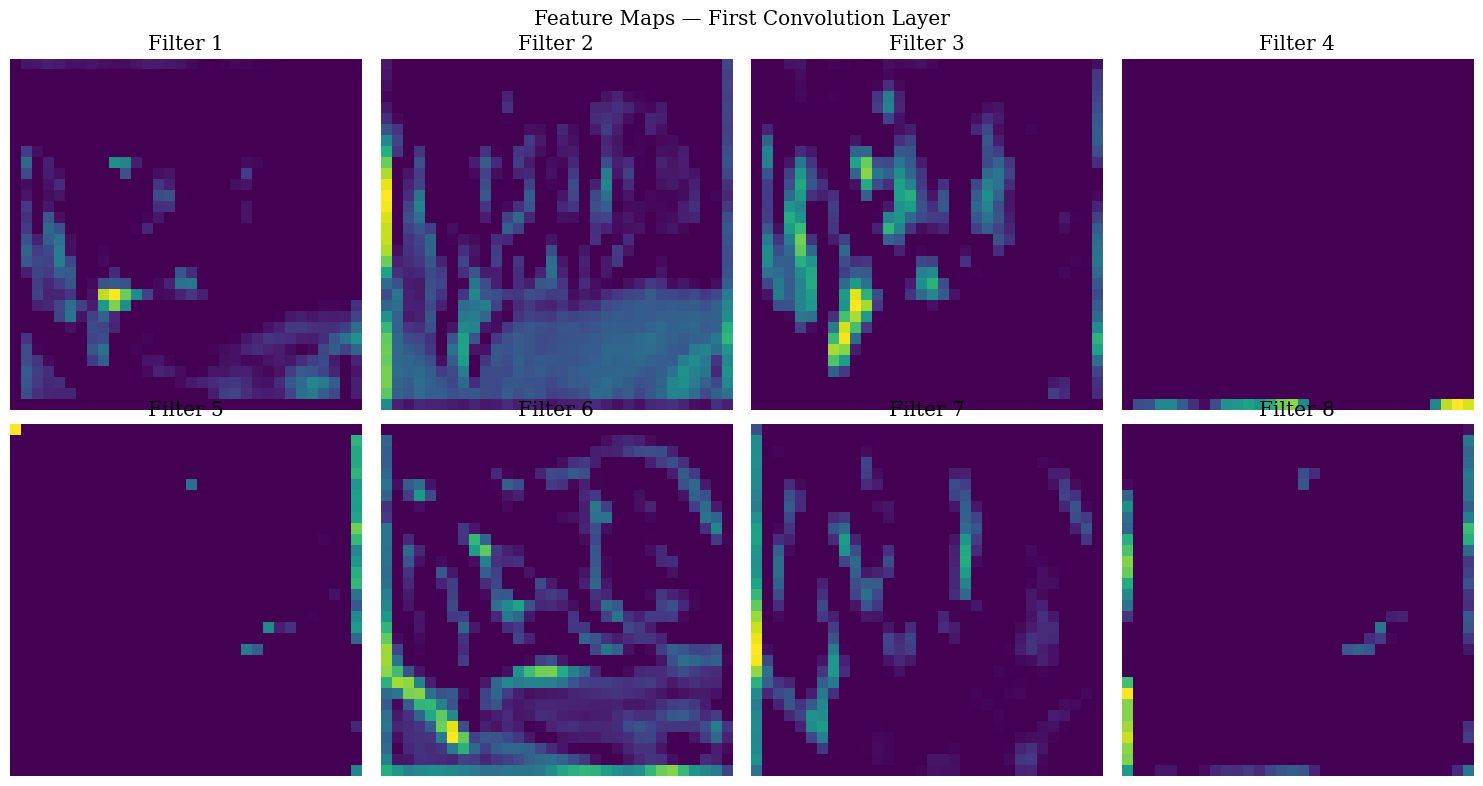

In [29]:
# Build a sub-model that outputs the activations of the first Conv2D layer
first_conv_layer = model.layers[0]
feature_map_model = models.Model(inputs=model.inputs, outputs=first_conv_layer.output)

img = X_test[0:1]
feature_maps = feature_map_model.predict(img)
print("Feature map shape:", feature_maps.shape)  # (1, 32, 32, 32) -> 32 filters

plt.figure(figsize=(15, 8))
for i in range(8):  # display at least 8 feature maps
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.title(f"Filter {i+1}")
    plt.axis('off')
plt.suptitle("Feature Maps — First Convolution Layer")
plt.savefig("feature_maps.eps", format="eps", dpi=600, bbox_inches="tight")
plt.tight_layout()
plt.show()

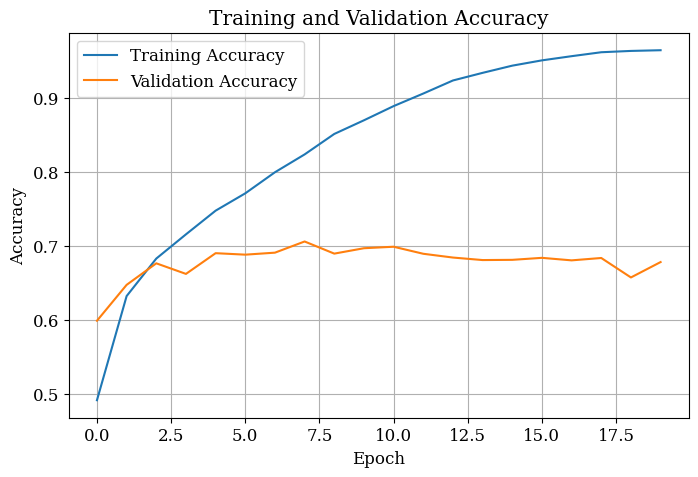

In [30]:
# TRAINING VS VALIDATION ACCURACY
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig("accuracy_plot.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

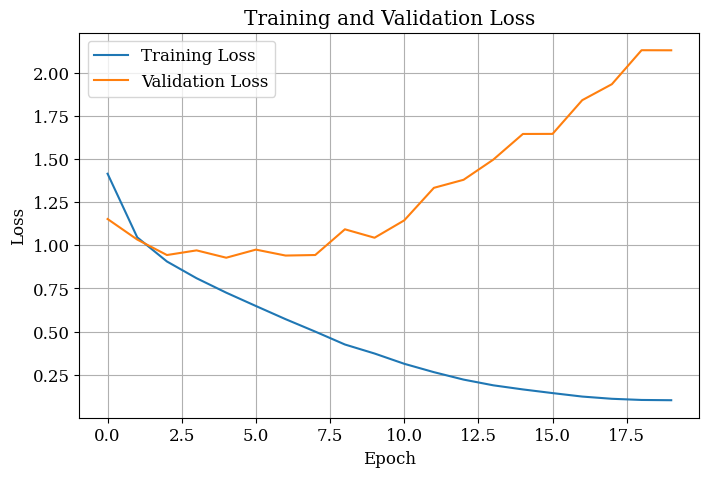

In [31]:
# TRAINING VS VALIDATION LOSS
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig("loss_plot.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:

# EVALUATE THE MODEL
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

In [ ]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test.flatten()

In [ ]:
#Evaluvation Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))

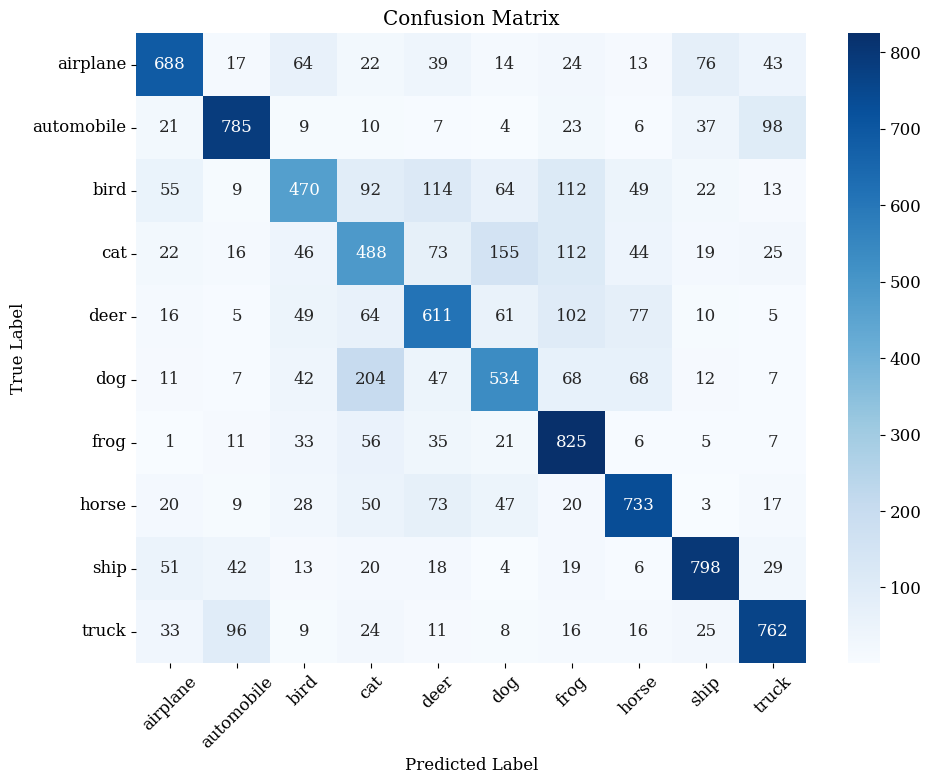

In [32]:
# PLOT CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap='Blues', annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xticks(np.arange(len(class_names)) + 0.5, class_names, rotation=45)
plt.yticks(np.arange(len(class_names)) + 0.5, class_names, rotation=0)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("confusion_matrix.eps", format="eps", dpi=600, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [33]:
#Max vs Avg Pooling
model_avgpool = models.Sequential([
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.AveragePooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.AveragePooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_avgpool.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_avgpool = model_avgpool.fit(X_train, y_train, epochs=20, batch_size=32,
                                     validation_split=0.2, verbose=1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4550 - loss: 1.5126 - val_accuracy: 0.5634 - val_loss: 1.2315
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5940 - loss: 1.1525 - val_accuracy: 0.5897 - val_loss: 1.1651
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6431 - loss: 1.0072 - val_accuracy: 0.6393 - val_loss: 1.0369
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6812 - loss: 0.9071 - val_accuracy: 0.6542 - val_loss: 0.9839
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7120 - loss: 0.8181 - val_accuracy: 0.6805 - val_loss: 0.9482
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7373 - loss: 0.7452 - val_accuracy: 0.6664 - val_loss: 0.9950
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7610 - loss: 0.6796 - val_accuracy: 0.6951 - val_loss: 0.9152
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7837 - loss: 0.6165 - 

In [34]:
avg_test_loss, avg_test_accuracy = model_avgpool.evaluate(X_test, y_test, verbose=0)

print(f"{'Pooling Type':<15}{'Test Accuracy':<15}{'Test Loss'}")
print(f"{'MaxPooling':<15}{test_accuracy:<15.4f}{test_loss:.4f}")
print(f"{'AvgPooling':<15}{avg_test_accuracy:<15.4f}{avg_test_loss:.4f}")

sample_out_max = layers.MaxPooling2D((2, 2))(sample_img)
sample_out_avg = layers.AveragePooling2D((2, 2))(sample_img)
print("MaxPooling output shape:", sample_out_max.shape)
print("AvgPooling output shape:", sample_out_avg.shape)

Pooling Type   Test Accuracy  Test Loss
MaxPooling     0.6694         2.2486
AvgPooling     0.6744         1.7950
MaxPooling output shape: (1, 16, 16, 3)
AvgPooling output shape: (1, 16, 16, 3)
